## IMPORTING LIBRARIES 

In [1]:
import pandas as pd      #library for data analysis
import matplotlib.pyplot as plt       #library for data visualization

## LOADING DATASET

#### I always keep a copy of the original data and perform analysis on the Copy t\of the original data

In [4]:
original_data = pd.read_csv('Table_data.csv')   # original — never touch this


In [21]:
df = original_data.copy()     # photocopy — we work on this

In [22]:
# Let's Check the shape of the data
print(df.shape)

(461, 16)


In [23]:
print(f'The dataset has {df.shape[0]} columns and {df.shape[1]} rows')

# df.shape[0]: shows the number of columns
# df.shape[1]: shows the number of rows

The dataset has 461 columns and 16 rows


In [24]:
df.head() #displays the first 5 records of the table

,Content,Video title,Video publish time,Duration,Average view duration,Average percentage viewed (%),Unique viewers,Subscribers gained,Subscribers lost,Likes,Comments added,Views,Watch time (hours),Subscribers,Impressions,Impressions click-through rate (%)
0,Total,NaN,NaN,NaN,0:00:20,75.81,0.0,6343,1555,107526,272,6326268,33261.3854,4788,10017488,5.49
1,lJ_t4-04vIU,Do you eat Appam everyday? B'coz its delicious...,"Sep 21, 2024",15.0,0:00:15,104.85,NaN,1867,303,50144,68,2876998,11400.9359,1564,5893112,4.93
2,5XPm8BWaU2w,Alia Bhatt And Gal Gadot had this same craving...,"Nov 24, 2024",30.0,0:00:23,77.07,NaN,1336,341,28682,45,1575327,10106.8591,995,1757274,7.80
3,lnGSJO9ewqI,Fast relief from Period Pain#beerbiceps #trs #...,"Dec 13, 2024",34.0,0:00:21,61.90,NaN,909,39,7710,4,476393,2780.0390,870,38244,3.24
4,6JAk6ZDhaks,Benefits of eating Bajra #healthierecipes24 #s...,"Jan 16, 2025",59.0,0:00:35,59.90,NaN,634,8,3713,13,288780,2491.9118,626,442707,8.70


#### Delete the Total row
Row 0 in the data is the "Total" row — it's not a video, it's just a summary YouTube added. If we keep it, it will destroy our analysis

In [25]:
# Remove the first row (Total row) and reset index

df = df.drop(index=0).reset_index(drop=True)
#drop=True in reset_index just means "don't keep the old row numbers, start fresh from 0."

print(df.shape) #should now be (460,16)
print(df.head(3)) #first 3 videos - should start with Appam video

(460, 16)
       Content                                        Video title  \
0  lJ_t4-04vIU  Do you eat Appam everyday? B'coz its delicious...   
1  5XPm8BWaU2w  Alia Bhatt And Gal Gadot had this same craving...   
2  lnGSJO9ewqI  Fast relief from Period Pain#beerbiceps #trs #...   

  Video publish time  Duration Average view duration  \
0       Sep 21, 2024      15.0               0:00:15   
1       Nov 24, 2024      30.0               0:00:23   
2       Dec 13, 2024      34.0               0:00:21   

   Average percentage viewed (%)  Unique viewers  Subscribers gained  \
0                         104.85             NaN                1867   
1                          77.07             NaN                1336   
2                          61.90             NaN                 909   

   Subscribers lost  Likes  Comments added    Views  Watch time (hours)  \
0               303  50144              68  2876998          11400.9359   
1               341  28682              45  15753

### Rename columns

Long messy columns are difficult to deal with so let's rename them to clean, short nor space names


In [31]:
# I wanted to rename the columns at once so, I created a list of new column name

df.columns= [
    'content_id',
    'video_title',
    'publish_date',
    'duration_sec',
    'avg_view_duration',
    'avg_perct_viewed',
    'unique_views',
    'subs_gained',
    'subs_lost',
    'likes',
    'comments',
    'views',
    'watch_time_hrs',
    'subscribers',
    'impressions',
    'ctr'
]

print(df.columns.tolist())

['content_id', 'video_title', 'publish_date', 'duration_sec', 'avg_view_duration', 'avg_perct_viewed', 'unique_views', 'subs_gained', 'subs_lost', 'likes', 'comments', 'views', 'watch_time_hrs', 'subscribers', 'impressions', 'ctr']


In [32]:
df.head()

,content_id,video_title,publish_date,duration_sec,avg_view_duration,avg_perct_viewed,unique_views,subs_gained,subs_lost,likes,comments,views,watch_time_hrs,subscribers,impressions,ctr
0,lJ_t4-04vIU,Do you eat Appam everyday? B'coz its delicious...,2024-09-21,15.0,15.0,104.85,NaN,1867,303,50144,68,2876998,11400.9359,1564,5893112,4.93
1,5XPm8BWaU2w,Alia Bhatt And Gal Gadot had this same craving...,2024-11-24,30.0,23.0,77.07,NaN,1336,341,28682,45,1575327,10106.8591,995,1757274,7.80
2,lnGSJO9ewqI,Fast relief from Period Pain#beerbiceps #trs #...,2024-12-13,34.0,21.0,61.90,NaN,909,39,7710,4,476393,2780.0390,870,38244,3.24
3,6JAk6ZDhaks,Benefits of eating Bajra #healthierecipes24 #s...,2025-01-16,59.0,35.0,59.90,NaN,634,8,3713,13,288780,2491.9118,626,442707,8.70
4,KOg4ZBO2aYs,"Parineeti or Raghav, who likes Paratha??#short...",2024-12-08,61.0,27.0,45.59,NaN,90,10,474,1,49751,381.9328,80,29098,4.90


### Fix data types
- publish_date is date
- avg_view_duration

<br>if Python thinks your date column is just text, it can't sort by date or calculate which month had most views.

In [33]:
#fix publish date - convert text to actual date
df['publish_date'] = pd.to_datetime(df['publish_date'])


In [34]:
# fix avg_view_duration - convert "0:00:15" text to total seconds(a number)

df['avg_view_duration'] = pd.to_timedelta(df['avg_view_duration']).dt.total_seconds()


In [35]:
#drop th unique column as all the values are missing

df = df.drop(columns=['unique_views'])


In [36]:
print(df.dtypes)

content_id                   object
video_title                  object
publish_date         datetime64[ns]
duration_sec                float64
avg_view_duration           float64
avg_perct_viewed            float64
subs_gained                   int64
subs_lost                     int64
likes                         int64
comments                      int64
views                         int64
watch_time_hrs              float64
subscribers                   int64
impressions                   int64
ctr                         float64
dtype: object


In [37]:
print(df.shape) #one column reduced

(460, 15)


In [39]:
#Sanity check
print(df.describe())

              publish_date  duration_sec  avg_view_duration  avg_perct_viewed  \
count                  450    460.000000       4.600000e+02        460.000000   
mean   2024-10-20 14:04:48     55.986957       2.281522e-08         52.346174   
min    2023-12-13 00:00:00      6.000000       7.000000e-09          8.370000   
25%    2024-05-02 12:00:00     32.000000       1.600000e-08         38.377500   
50%    2024-10-05 00:00:00     46.000000       2.000000e-08         49.005000   
75%    2025-03-12 06:00:00     58.000000       2.500000e-08         60.660000   
max    2026-01-13 00:00:00    591.000000       1.460000e-07        260.960000   
std                    NaN     58.694548       1.224952e-08         24.791573   

       subs_gained   subs_lost         likes    comments         views  \
count   460.000000  460.000000    460.000000  460.000000  4.600000e+02   
mean     13.158696    1.689130    232.852174    0.589130  1.369458e+04   
min       0.000000    0.000000      0.000000    

#### This gives you the min, max, average of every column. Run it and just tell me:

- What is the max views any single video got?<br>
- What is the average CTR?

"avg_view_duration" : The right way to convert "0:00:15" to seconds .


In [40]:
#this is to convert 0:00:15 to actual seconds as a number : 15.0 seconds

df['avg_view_duration'] = pd.to_timedelta(
    original_data['Average view duration'].iloc[1:]
).dt.total_seconds().values

print(df['avg_view_duration'].head())

0    15.0
1    23.0
2    21.0
3    35.0
4    27.0
Name: avg_view_duration, dtype: float64


In [41]:
df.head()

,content_id,video_title,publish_date,duration_sec,avg_view_duration,avg_perct_viewed,subs_gained,subs_lost,likes,comments,views,watch_time_hrs,subscribers,impressions,ctr
0,lJ_t4-04vIU,Do you eat Appam everyday? B'coz its delicious...,2024-09-21,15.0,15.0,104.85,1867,303,50144,68,2876998,11400.9359,1564,5893112,4.93
1,5XPm8BWaU2w,Alia Bhatt And Gal Gadot had this same craving...,2024-11-24,30.0,23.0,77.07,1336,341,28682,45,1575327,10106.8591,995,1757274,7.80
2,lnGSJO9ewqI,Fast relief from Period Pain#beerbiceps #trs #...,2024-12-13,34.0,21.0,61.90,909,39,7710,4,476393,2780.0390,870,38244,3.24
3,6JAk6ZDhaks,Benefits of eating Bajra #healthierecipes24 #s...,2025-01-16,59.0,35.0,59.90,634,8,3713,13,288780,2491.9118,626,442707,8.70
4,KOg4ZBO2aYs,"Parineeti or Raghav, who likes Paratha??#short...",2024-12-08,61.0,27.0,45.59,90,10,474,1,49751,381.9328,80,29098,4.90


### Save the Clean Data

In [42]:
df.to_csv('healthie_recipes_clean.csv', index=False)
print("Clean data saved!")
print(df.shape)  # should be (460, 15)

Clean data saved!
(460, 15)


#### Analysis begins here

#### The questions I asked my data
|Questions | Why it matters|
|---|---|
|1) Which are your top 10 videos by views? | See what contents works|
|2) Which videos gained the most subscribers? | See ehat converts viewers to subs
|3) High views but low subscribers - which videos? | See what converts viewers to subs
|4) Which videos have the best CTR? | Find the leakage|
|5) How have your views grown over time? | See channel growth trend

#### Q1 - Top 10 videos by views


In [44]:
top_10 = df[['video_title', 'views', 'likes', 'subs_gained']].sort_values('views', ascending=False).head(10)

#df[[...]] : pick only these 4 columns
# .sort_values('views', ascending=False) : sort highest to lowest
# .head(10) : display top 10

In [46]:
print(top_10)

# Here is a pattern that, most videos at the top are 1) food benefits, 2) Celebrity related

                                          video_title    views  likes  \
0   Do you eat Appam everyday? B'coz its delicious...  2876998  50144   
1   Alia Bhatt And Gal Gadot had this same craving...  1575327  28682   
2   Fast relief from Period Pain#beerbiceps #trs #...   476393   7710   
3   Benefits of eating Bajra #healthierecipes24 #s...   288780   3713   
4   Parineeti or Raghav, who likes Paratha??#short...    49751    474   
7   Benefits of eating Raw Banana💚#healthierecipes...    48674    585   
5   Raj Thackeray's Most favourite Vada😋✨👌🏻 #sabud...    39595    354   
11  Wamiqa Gabbi & Rajkumar Rao love maggi🍜 #healt...    34465    257   
6   Megastar Chiranjeevi’s Veg Treat for Keerthy!#...    32369    661   
12  ✨Bhaji with Jackie Shroff & Farah Khan✨#health...    30716    476   

    subs_gained  
0          1867  
1          1336  
2           909  
3           634  
4            90  
7            57  
5            64  
11           21  
6            49  
12           17 

#### Q2 - Which Videos Gained the Most Subscribers?

In [47]:
top10_subs = df[['video_title', 'views', 'subs_gained']].sort_values('subs_gained', ascending=False).head(10)

In [48]:
print(top10_subs)

                                          video_title    views  subs_gained
0   Do you eat Appam everyday? B'coz its delicious...  2876998         1867
1   Alia Bhatt And Gal Gadot had this same craving...  1575327         1336
2   Fast relief from Period Pain#beerbiceps #trs #...   476393          909
3   Benefits of eating Bajra #healthierecipes24 #s...   288780          634
4   Parineeti or Raghav, who likes Paratha??#short...    49751           90
5   Raj Thackeray's Most favourite Vada😋✨👌🏻 #sabud...    39595           64
7   Benefits of eating Raw Banana💚#healthierecipes...    48674           57
6   Megastar Chiranjeevi’s Veg Treat for Keerthy!#...    32369           49
8   Abs are made in the kitchen🏋🏻‍♂️👨🏻‍🍳#shorts #f...    25225           42
20  Gym Coach Nitesh's workout tip#shorts#shortsfe...    12512           30


- 2.8 million people viewed
- Only 1,867 actually became loyal customers (subscribers)

Reason: The channel has many shorts videos
- Shorts get good views  by not real subscribers
- No clear "subscribe" hook


In [49]:
#calculate subscriber conversion rate per video
#conversion rate : Out of every 100 people who watched your video, how many pressed Subscribe?

df['conversion_rate'] = (df['subs_gained'] / df['views']) * 100

#see the worst converters - high views, low subs

leakage = df[['video_title','views','subs_gained','conversion_rate']].sort_values('views', ascending=False).head(10)

In [50]:
print(leakage)

#So 0.06% conversion rate. Industry standard is 1-3%. 
#The channel is 20x lower than average — that's the story the data is telling! 📖

                                          video_title    views  subs_gained  \
0   Do you eat Appam everyday? B'coz its delicious...  2876998         1867   
1   Alia Bhatt And Gal Gadot had this same craving...  1575327         1336   
2   Fast relief from Period Pain#beerbiceps #trs #...   476393          909   
3   Benefits of eating Bajra #healthierecipes24 #s...   288780          634   
4   Parineeti or Raghav, who likes Paratha??#short...    49751           90   
7   Benefits of eating Raw Banana💚#healthierecipes...    48674           57   
5   Raj Thackeray's Most favourite Vada😋✨👌🏻 #sabud...    39595           64   
11  Wamiqa Gabbi & Rajkumar Rao love maggi🍜 #healt...    34465           21   
6   Megastar Chiranjeevi’s Veg Treat for Keerthy!#...    32369           49   
12  ✨Bhaji with Jackie Shroff & Farah Khan✨#health...    30716           17   

    conversion_rate  
0          0.064894  
1          0.084808  
2          0.190809  
3          0.219544  
4          0.180901 

#### Insight 1
- The Appam video brought 2.8M views but converted only 0.06% to subscribers - 20x below the industry benchmark of 1-3%. This suggests Shorts content attracts casual viewers but fails to build a loyal audience.

#### Q4 — CTR Analysis
- CTR: click through rate
- High CTR = your_title + thumbnail but
- Low CTR = people are scrolling past your video


In [51]:
top10_ctr = df[['video_title','impressions','views','ctr']].sort_values('ctr', ascending=False).head(10)
print(top10_ctr)

                                           video_title  impressions    views  \
57   Easy Recipe for Batatyacha Thalipeeth#rajthack...        21342     5218   
7    Benefits of eating Raw Banana💚#healthierecipes...       196060    48674   
411  Tasty Quick and easy Sweet Potato snack!Must T...          217      106   
39   ✨How to toast Sesame🤍 #sesame #seeds #tipsandt...        49829    10197   
177  ♥️Navratri Day 6| Honey🍎 Halwa #shorts#honey#a...         1514      716   
12   ✨Bhaji with Jackie Shroff & Farah Khan✨#health...        18434    30716   
3    Benefits of eating Bajra #healthierecipes24 #s...       442707   288780   
219  Easy Chana drink #drink #food #sattudrinkrecip...         3205      623   
50   Jackie Shroff's Special Chai recipe#jackieshro...        16783     7001   
1    Alia Bhatt And Gal Gadot had this same craving...      1757274  1575327   

       ctr  
57   10.82  
7    10.58  
411  10.14  
39    9.34  
177   9.18  
12    8.99  
3     8.70  
219   8.11  
50

C:\Users\HP\AppData\Local\Temp\ipykernel_12184\1960390336.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_ctr, x='short_title', y='ctr', palette='viridis', linewidth=2.5)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


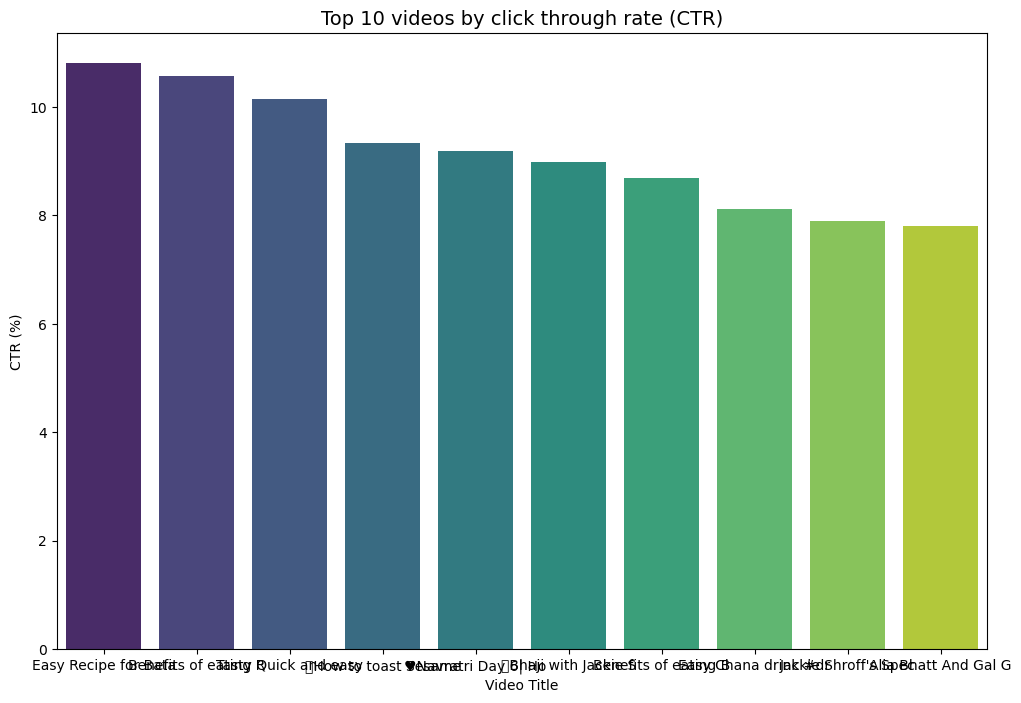

In [59]:
#plotted a graph to actually view

import seaborn as sns

#shorten titles to first 20 characters so they fit on chart
top10_ctr['short_title'] = top10_ctr['video_title'].str[:20]

#Plot
plt.figure(figsize=(12,8))
sns.barplot(data=top10_ctr, x='short_title', y='ctr', palette='viridis', linewidth=2.5)

plt.title('Top 10 videos by click through rate (CTR)', fontsize=14)
plt.xlabel('Video Title')
plt.ylabel('CTR (%)')
plt.show()

#### What this chart is telling
- "Easy recipe.." : this title has high CTR = 11% : that title/ thumbnail is very clickable
- All top 10 are between 8-11% CTR - these are actually excellent! Average views are 2-5%
- Celebrity videos appear in top 10: people click on celebrity content

#### Insight 2
- Top performing videos but CTR averaged 9%+ - nearly double the industry benchmark of 2-5%.
- However, high CTR did not always translate to high views or subscribers, suggesting Youtube's algorithm isn't distributing impressions evenly.

#### Q5 Views Over Time
- Is the channel growing or dying
  

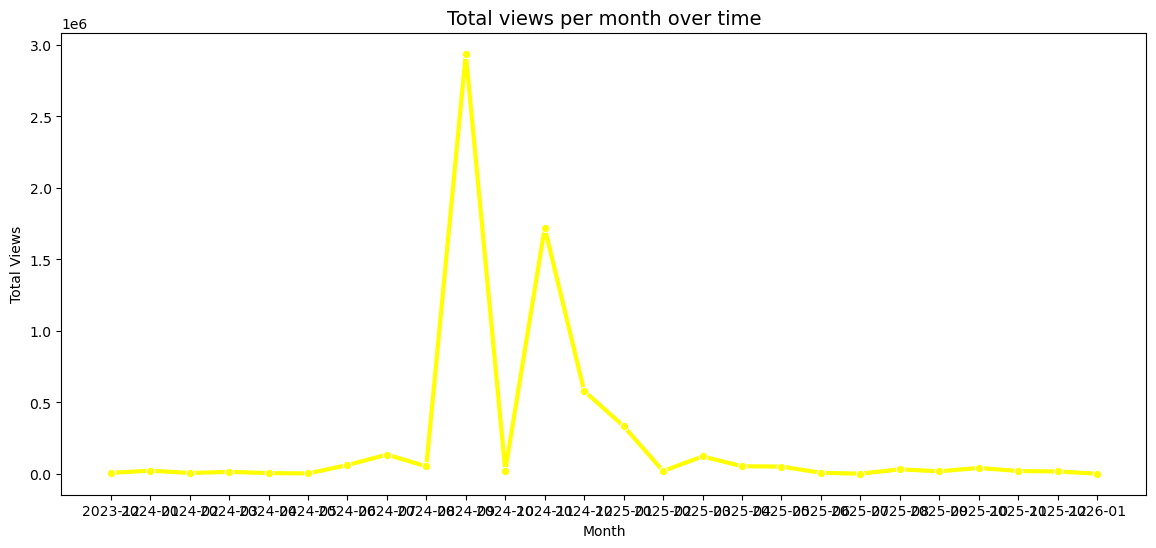

In [60]:
#Extract month and year from publish date
df['month_year'] = df['publish_date'].dt.to_period('M')

#Group by month, sum views
views_over_time = df.groupby('month_year')['views'].sum().reset_index()
views_over_time['month_year'] = views_over_time['month_year'].astype(str)

#Plot
plt.figure(figsize=(14,6))
sns.lineplot(data=views_over_time, x='month_year', y='views', marker='o', color='yellow', linewidth=3)

plt.title('Total views per month over time', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Views')
plt.show()

#### Insight 3
- 96% of total channel views were genearted in just 2 months (Sep-Oct 2024), driven by one viral short. The channel lacked consistent content strategy to sustain or build on viral momentum.

### word Cloud - Most used words in the titles
- which words appear most in your Video Titles? This matters as it tells you what topics I cover most - and I can compare it against TOP performing videos to see if you're making enough content around what works.
- Did I create content what audience liked

In [62]:
#install WORD CLOUD

!pip install wordcloud

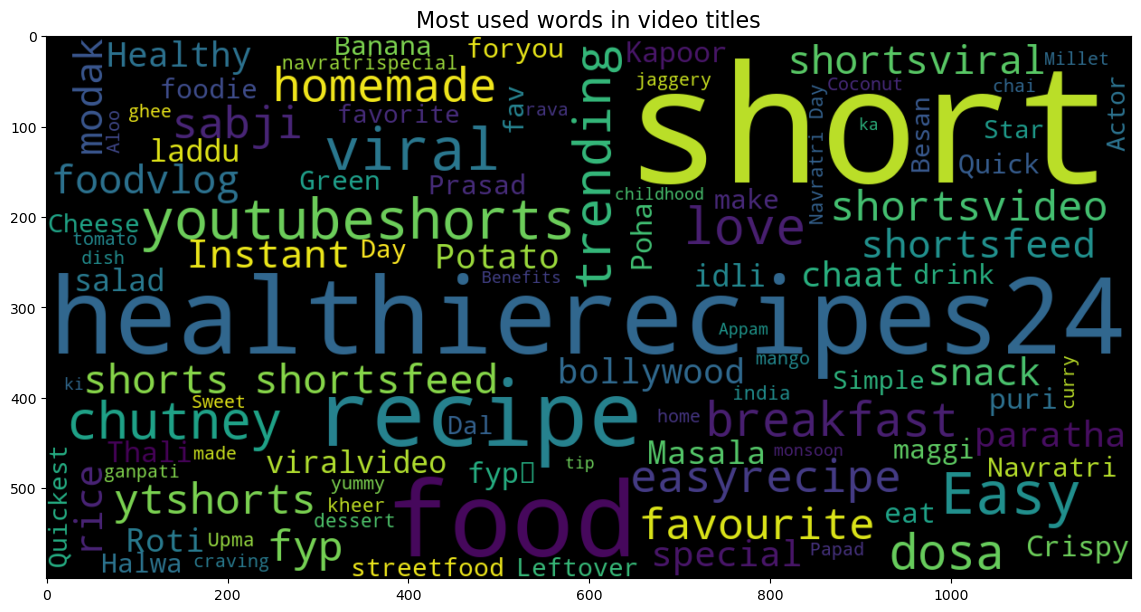

In [64]:
from wordcloud import WordCloud

#join all video titles into one big text
all_titles = ' '.join(df['video_title'].dropna().tolist())

#Generate word cloud
wordcloud = WordCloud(
    width = 1200,
    height=600,
    background_color='black',
    colormap = 'viridis',
    max_words=100
).generate(all_titles)


#PLOT

plt.figure(figsize=(14,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most used words in video titles', fontsize=16)
plt.savefig('wordcloud_titles.png')
plt.show()

### What does the word Cloud say?
- Bigger word = used more times in your titles

|Word  |  Meaning|
|---|---|
| short, youtubeshorts, shortsviral | Most used tags for reach
| healthierecipes24 | Channel name is in Titles: Show Good Branding
| food, recipe, homemade | Core content identity
| viral, trending, fyp | These are most used tags for colabs, or any trending content
| bollywood, Kapoor | Celebrity content mostly viewed
| breakfast, dosa, chutney, paratha | most searched food names

#### Insight 4
- Word frequency analysis reveals the channel has more Shorts, as the consumer/ viewers love short content more than long videos. This channel has content that is celebrity / bollywood content with food recipes created an unclear brand - viewers don't know what to consistently expect, reducing subscriber loyalty.

In [65]:
#views vs subs_gained
df.head()

,content_id,video_title,publish_date,duration_sec,avg_view_duration,avg_perct_viewed,subs_gained,subs_lost,likes,comments,views,watch_time_hrs,subscribers,impressions,ctr,conversion_rate,month_year
0,lJ_t4-04vIU,Do you eat Appam everyday? B'coz its delicious...,2024-09-21,15.0,15.0,104.85,1867,303,50144,68,2876998,11400.9359,1564,5893112,4.93,0.064894,2024-09
1,5XPm8BWaU2w,Alia Bhatt And Gal Gadot had this same craving...,2024-11-24,30.0,23.0,77.07,1336,341,28682,45,1575327,10106.8591,995,1757274,7.80,0.084808,2024-11
2,lnGSJO9ewqI,Fast relief from Period Pain#beerbiceps #trs #...,2024-12-13,34.0,21.0,61.90,909,39,7710,4,476393,2780.0390,870,38244,3.24,0.190809,2024-12
3,6JAk6ZDhaks,Benefits of eating Bajra #healthierecipes24 #s...,2025-01-16,59.0,35.0,59.90,634,8,3713,13,288780,2491.9118,626,442707,8.70,0.219544,2025-01
4,KOg4ZBO2aYs,"Parineeti or Raghav, who likes Paratha??#short...",2024-12-08,61.0,27.0,45.59,90,10,474,1,49751,381.9328,80,29098,4.90,0.180901,2024-12


#### Views Chart

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


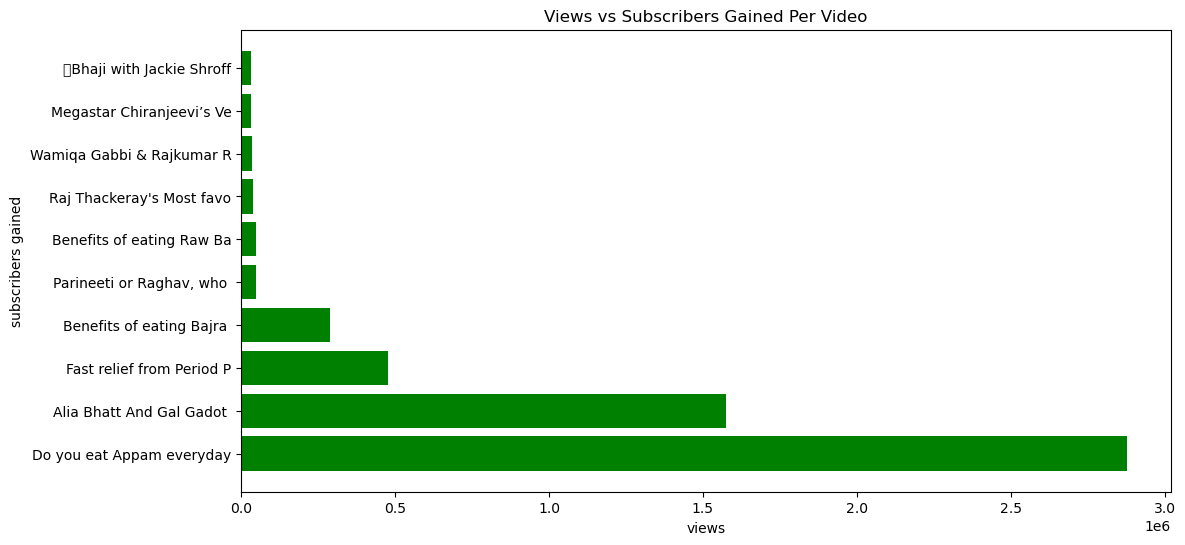

In [73]:
top10_subs_gained = df[['video_title','views', 'subs_gained']].sort_values('views', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10_subs_gained['video_title'].str[:25], top10_subs_gained['views'], color='green')

plt.title('Views vs Subscribers Gained Per Video')
plt.xlabel('views')
plt.ylabel('subscribers gained')
plt.show()

#### Subscribers gained

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


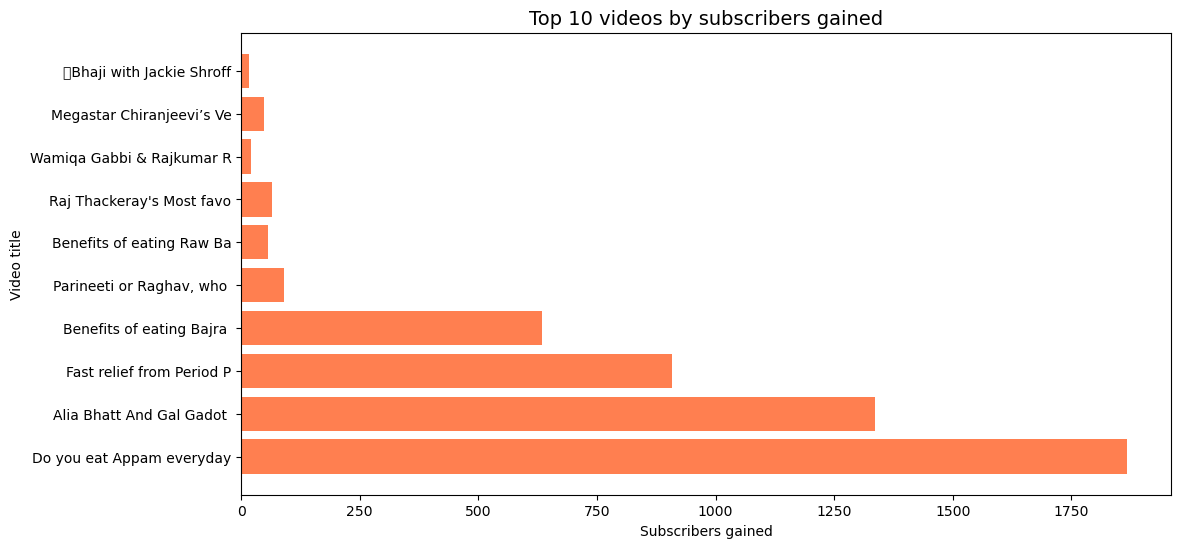

In [76]:
plt.figure(figsize=(12,6))
plt.barh(top10_subs_gained['video_title'].str[:25], top10_subs_gained['subs_gained'], color='coral')
plt.title('Top 10 videos by subscribers gained', fontsize=14)
plt.xlabel('Subscribers gained')
plt.ylabel('Video title')
plt.show()

#### Engagement Analysis
- Engagement = how much peopleinteract with your video, not just watch it.
- engagement_rate = (like + comments) / views * 100

In [81]:
# Calculate engagement rate per video

df['engagement_rate'] = ((df['likes'] + df['comments']) / df['views']) * 100

df['engagement_rate'] = df['engagement_rate'].round(2)

#top 10 most engaging videos

top10_engagement = df[['video_title', 'views', 'likes', 'comments', 'engagement_rate']]\
.sort_values('engagement_rate', ascending=False).head(10)

print(top10_engagement)

                                           video_title  views  likes  \
456                                   February 5, 2025      2      1   
448  ✨Very First Vlog🪔Diwali Vlog ✨🪔#diwali #health...     15      5   
447  Mixed flour roti✨💪🏻#breakfast#healthierecipes2...     25      8   
452  Crisp Comfort Sandwish#healthierecipes24 #food...      5      1   
433  Secret Masala Khichdi recipe✨#healthierecipes2...     58     11   
436  Kanda Bhajji✨🤤🔥 #kanda #bhajji #bajji #shorts ...     37      7   
419  Quick Yummy Amla Chutney#youtubeshorts #trendi...     63     11   
445  Easy Upma recipe ✨ #shorts #upma #easyrecipe #...     26      4   
439  Veg High protein meal by Viral Gym coach Nites...     35      5   
422  Frankie🌯✨ #newsong #midnight #cravings #shorts...     57      8   

     comments  engagement_rate  
456         0            50.00  
448         0            33.33  
447         0            32.00  
452         0            20.00  
433         0            18.97  
436      

#### Showing videos with top comments

In [84]:
#filter videos with atleast 1 comment
df_comments = df[df['comments'] >= 1].copy()

#sort by comments highest first

top_comments = df_comments[['video_title', 'views', 'likes', 'comments', 'engagement_rate']]\
.sort_values('comments', ascending=False).head(10)

print(top_comments)

                                          video_title    views  likes  \
0   Do you eat Appam everyday? B'coz its delicious...  2876998  50144   
1   Alia Bhatt And Gal Gadot had this same craving...  1575327  28682   
3   Benefits of eating Bajra #healthierecipes24 #s...   288780   3713   
14  Homemade Cashews!#healthierecipes24 #why #food...    19090    569   
9   Celebrities that love Bengali Puchka/Fuchka #h...    23583    631   
2   Fast relief from Period Pain#beerbiceps #trs #...   476393   7710   
7   Benefits of eating Raw Banana💚#healthierecipes...    48674    585   
20  Gym Coach Nitesh's workout tip#shorts#shortsfe...    12512    762   
54  Nitin Gadakari's Vangi Potato sabji #food #eas...     4704     70   
53  The 'OG' Modak♥️✨|Ukdiche Modak#ukdichemodak #...     5217    173   

    comments  engagement_rate  
0         68             1.75  
1         45             1.82  
3         13             1.29  
14         9             3.03  
9          4             2.69  
2   

#### Insight 5
- Despite Appam  driving 2.8M views, engagement rate was only 1.75%. Smaller videos like Gym Coach Nitesh(12.5k views) achieved 6.11% engagement - 3X higher - suggesting niche focused content drives stornger audience connection than viral Shorts.

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


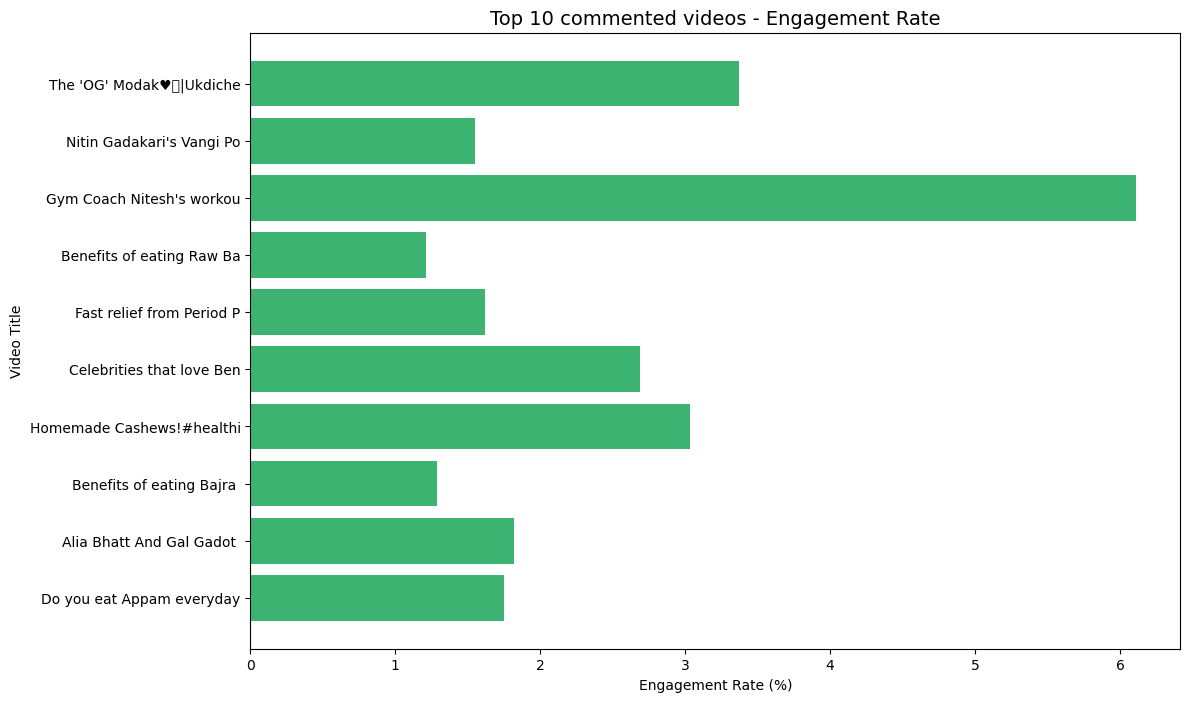

In [87]:
plt.figure(figsize=(12,8))
plt.barh(top_comments['video_title'].str[:25],top_comments['engagement_rate'],color='mediumseagreen')

plt.title('Top 10 commented videos - Engagement Rate', fontsize=14)
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Video Title')
plt.show()

#### Correlation Analysis
- When views go up — do subscribers also go up?
- When CTR goes up — do views also go up?
- When watch time goes up — do subs go up?

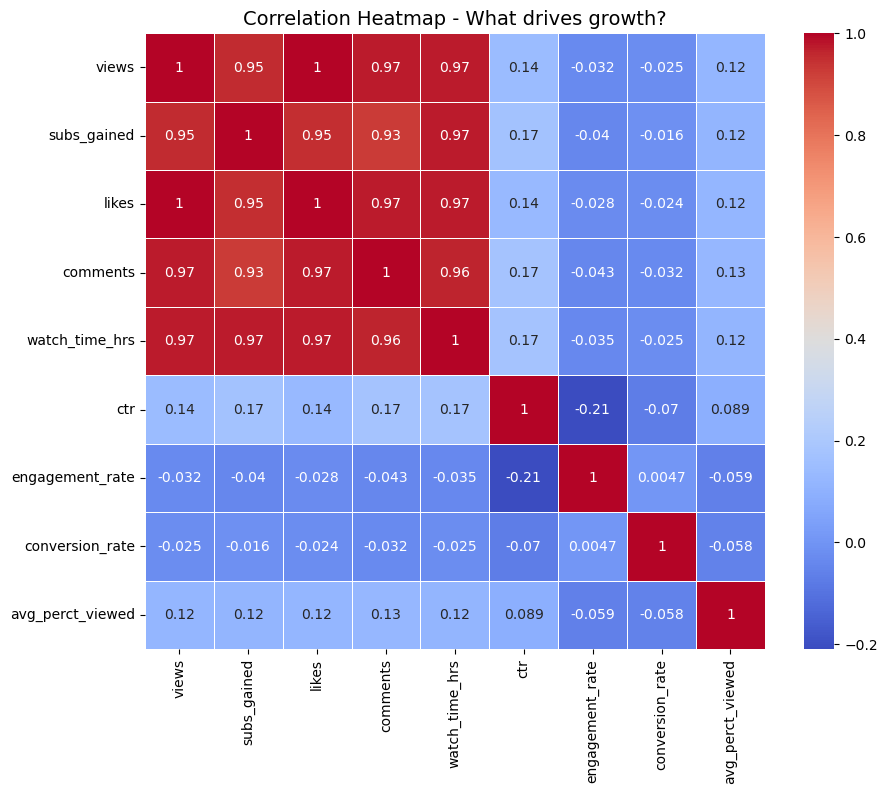

In [89]:
#select only numeric columns for correlation

corr_cols = ['views', 'subs_gained', 'likes', 'comments', 'watch_time_hrs', 'ctr', 'engagement_rate', 'conversion_rate', 'avg_perct_viewed']

correlation = df[corr_cols].corr()

#Plot as heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot = True, cmap='coolwarm', linewidth=0.5)

plt.title('Correlation Heatmap - What drives growth?', fontsize=14)
plt.show()

- Dark red = strong positive relationship(both go up together)
- Dark blue = negative realtionship(one goes up , other goes down)
- Light blue = no relationship(they don't affect each other)
- The diagonal is always 1.0 - because any metric perfectly correlates with itself!

* The Red Box (top left 5x5)
views, subs_gained, likes, comments, watch_time_hrs all score 0.93 - 1.0 with each other.
This means:

"Videos that get more views automatically get more likes, comments, watch time AND subscribers — they all move together."

* CTR Row (middle)
CTR scores only 0.14 with views — nearly zero!
This means:

"A high CTR does NOT guarantee high views. YouTube isn't showing my high-CTR videos to enough people."

* Engagement Rate = -0.04 with subs_gained
Negative! This means:

"Videos with high engagement rate actually gain FEWER subscribers — proving my small videos engage people but don't convert them to subs."


* Conversion Rate = -0.025 with views
Nearly zero — meaning:

"Getting more views has zero impact on subscriber conversion."



#### Insight 6
- Correlation analysis revelaed that while views, likes, watch time and subscribers move together strongly(0.95+), CTR and engagement rate show near-zero correlation with growth metrics. This proves the channel's growth is driven purely by volume - not content quality or audience targeting.

#### Save the clean data

In [ ]:
df.